In [1]:
# %%
import matplotlib.pyplot as plt
import numpy as np
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.optimize import minimize, least_squares
from joblib import Parallel, delayed
import time as t
from scipy.linalg import sqrtm, inv, eigh, expm, expm_frechet
import gc
import argparse
import os


In [28]:

# # %%
# parser = argparse.ArgumentParser()
# parser.add_argument("--outdir", type=str)
# args = parser.parse_args()
# os.makedirs(args.outdir, exist_ok=True)

# %%
#Control Hamiltonian
def H_c(phi=[], beta=1, omega=1, J=1):
    H_c = np.array([omega*(np.cos(phi[i])*J_x+np.sin(phi[i])*J_y)+ beta/(2*J) * J_z2 for i in range(len(phi))])
    return H_c

#Parameters
rng = np.random.default_rng(3)
J = 1 #Spin of system
t_steps = 1000 #Number of Trotter steps to simulate
delta_t = 0.001 #Time step for Trotter evolution
beta = 50 #Strength of nonlinear term in control Hamiltonian
omega = 50 #Strength of linear term in control Hamiltonian
w_stdev = 0.01 #Standard deviation of true parameter values (for random generation)
#w_true = np.random.normal(0, w_stdev, 3) #True parameter values
w_true = np.array([40.02, 12.53, 23.75])
w_init = [0, 0, 0] #Initial guess for parameters
batch_size = 50 #Number of parallel optimizations
iter = 300 #Total number of optimization iterations
random_phase_steps = 1000 #Number of random phase values to repeat
#measurement_steps_array = np.logspace(1, np.log10(t_steps), num=10, dtype=int) #Array of different numbers of measurements to simulate
measurement_steps_array = np.array([100]) #Array of different numbers of measurements to simulate
dim = int(2*J+1)
G = 8.9e-7 #Rotation sensitivity in radians per Hz
N_a = 2e5 #Number of atoms in ensemble
theta_scs = np.pi/2 #Initial spin coherent state parameters
phi_scs = 0 #Initial spin coherent state parameters
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
J_z2 = J_z @ J_z
in_state = spin_coherent(J, theta_scs, phi_scs, type = 'dm').full()
obs_0 = J_y #Initial observable
folder = "/users/agarcia2001/data_trotter_least_squares_1" #Folder to save results

if np.array_equal(obs_0, J_x):
    obs_0_string = 'J_x'
elif np.array_equal(obs_0, J_y):
    obs_0_string = 'J_y'
elif np.array_equal(obs_0, J_z):
    obs_0_string = 'J_z'
else:
    obs_0_string = 'unknown'



def commutator(A, B):
   """Compute the commutator [A, B] = AB - BA."""
   return A @ B - B @ A

def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def fidelity(rho, sigma):
    # Compute sqrt(rho)
    sqrt_rho = sqrtm(rho)
    # Compute sqrt_rho * sigma * sqrt_rho
    inner = sqrt_rho @ sigma @ sqrt_rho
    # Compute sqrt of the inner matrix
    sqrt_inner = sqrtm(inner)
    # Take the trace and square the result
    fidelity_value = np.real(np.trace(sqrt_inner)) ** 2
    return fidelity_value

def repeated_random_array(total_len, repeat_n, low=0.0, high=1.0):
    n_unique = int(np.ceil(total_len / repeat_n))
    vals = rng.uniform(low, high, size=n_unique)
    arr = np.repeat(vals, repeat_n)
    return arr[:total_len]

def compute_expectations(w):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U_w = expm(-1j * delta_t * H_w)
    U_w_dagger = expm(1j * delta_t * H_w)

    obs = obs_0

    expectation = []
    del_expect_x = []
    del_expect_y = []
    del_expect_z = []

    # Frechet derivatives
    del_U_w_x = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_x, compute_expm=False)
    del_U_w_y = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_y, compute_expm=False)
    del_U_w_z = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_z, compute_expm=False)

    del_U_w_dagger_x = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_x, compute_expm=False)
    del_U_w_dagger_y = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_y, compute_expm=False)
    del_U_w_dagger_z = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_z, compute_expm=False)

    del_obs_x = np.zeros_like(obs)
    del_obs_y = np.zeros_like(obs)
    del_obs_z = np.zeros_like(obs)

    for i in range(t_steps+1):

        # Record only at measurement steps
        if i in measurement_indices:
            expectation.append(expect(obs, in_state))
            del_expect_x.append(expect(del_obs_x, in_state))
            del_expect_y.append(expect(del_obs_y, in_state))
            del_expect_z.append(expect(del_obs_z, in_state))
        if i == t_steps:
            break

        # Update derivatives
        del_obs_x = (del_U_w_dagger_x @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ U_w + 
                     U_w_dagger @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ del_U_w_x + 
                     U_w_dagger @ U_c_dagger_array[i] @ del_obs_x @ U_c_array[i] @ U_w)

        del_obs_y = (del_U_w_dagger_y @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ U_w + 
                     U_w_dagger @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ del_U_w_y + 
                     U_w_dagger @ U_c_dagger_array[i] @ del_obs_y @ U_c_array[i] @ U_w)

        del_obs_z = (del_U_w_dagger_z @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ U_w + 
                     U_w_dagger @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ del_U_w_z + 
                     U_w_dagger @ U_c_dagger_array[i] @ del_obs_z @ U_c_array[i] @ U_w)

        # Update observable
        obs = U_w_dagger @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ U_w

    return (np.array(expectation),
            np.array(del_expect_x),
            np.array(del_expect_y),
            np.array(del_expect_z))

def residuals(w, M_vec):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U_w = expm(-1j * delta_t * H_w)
    U_w_dagger = U_w.conj().transpose()

    obs = obs_0
    obs_trace = []

    for i in range(t_steps+1):

        if i in measurement_indices:
            obs_trace.append(expect(obs, in_state))
        if i == t_steps:
            break
        obs = U_w_dagger @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ U_w

    return M_vec - np.array(obs_trace)

def w_estimate_linearized(gaussian_noise, expectation_true, w_init):
    #expectation, del_expect_x, del_expect_y, del_expect_z = compute_expectations(w_init)
    M_vec = expectation_true + gaussian_noise
    #J_matrix = np.vstack((del_expect_x, del_expect_y, del_expect_z)).transpose()
    #w_estimate = w_init + inv(J_matrix.transpose() @ J_matrix) @ J_matrix.transpose() @ (M_vec - expectation)
    result = least_squares(residuals, x0 = w_init, args=(M_vec,), method='lm')
    return result


In [29]:


# %%

runs = len(measurement_steps_array)
runtime_array = np.zeros(runs)
covar_array = [None] * runs
mean_array = [None] * runs
std_array = [None] * runs
fisher_array = [None] * runs
w_est_all_runs = [None] * runs
w_est_dict_failures = [None] * runs
bias = [None] * runs
CRB_diff_eig = [None] * runs
fisher_shannon_entropy = [None] * runs

for k in range(runs):
    start_time = t.time()
    shannon = []
    w_est = []
    failures = []
    measurement_steps = measurement_steps_array[k]
    measurement_indices = np.linspace(0, t_steps, measurement_steps, dtype=int)
    N_p = 9.6e8 / (measurement_steps)
    sn_sd = 1/(np.sqrt(N_p)*G*N_a)
    phi = repeated_random_array(t_steps, random_phase_steps, low=0.0, high=2*np.pi)
    H_c_array = H_c(phi, beta, omega, J)
    U_c_array = [expm(-1j * delta_t * H_c_array[i]) for i in range(t_steps)]
    U_c_dagger_array = [U_c_array[i].conj().transpose() for i in range(t_steps)]

    #Calculate expectation value
    expectation, del_expect_x, del_expect_y, del_expect_z = compute_expectations(w_true)
    


0.0018131944504716374


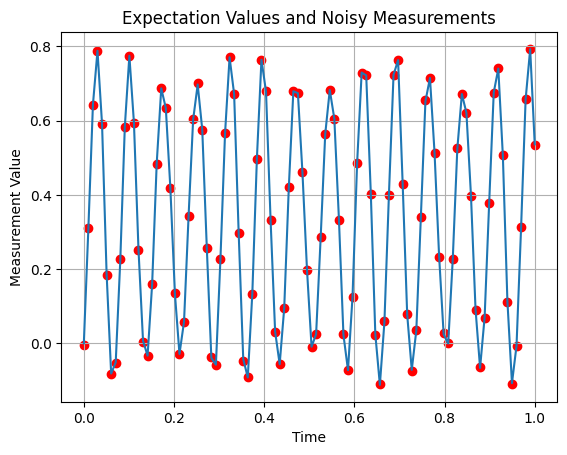

In [30]:
noise = rng.normal(0, sn_sd, size=len(expectation))
print(sn_sd)
M_vec = expectation + noise
time = np.linspace(0, t_steps*delta_t, len(M_vec))
plt.plot(time, expectation, label='Expectation')
plt.scatter(time, M_vec, color='red', label='Measurements')
plt.xlabel('Time')
plt.ylabel('Measurement Value')
plt.title('Expectation Values and Noisy Measurements')
plt.grid()
plt.show()

In [ ]:
    #Calculate fisher information
    # for j in np.arange(0, t_steps+1, 10):
    #     del_expectation_x = del_expect_x[:j]
    #     del_expectation_y = del_expect_y[:j]
    #     del_expectation_z = del_expect_z[:j]
    #     fisher_matrix = np.zeros((3, 3))
    #     fisher_matrix[0, 0] = np.vdot(del_expectation_x, del_expectation_x) / sn_sd**2
    #     fisher_matrix[1, 1] = np.vdot(del_expectation_y, del_expectation_y) / sn_sd**2
    #     fisher_matrix[2, 2] = np.vdot(del_expectation_z, del_expectation_z) / sn_sd**2
    #     fisher_matrix[0, 1] = np.vdot(del_expectation_x, del_expectation_y) / sn_sd**2
    #     fisher_matrix[0, 2] = np.vdot(del_expectation_x, del_expectation_z) / sn_sd**2
    #     fisher_matrix[1, 2] = np.vdot(del_expectation_y, del_expectation_z) / sn_sd**2
    #     fisher_matrix[1, 0] = fisher_matrix[0, 1]
    #     fisher_matrix[2, 0] = fisher_matrix[0, 2]
    #     fisher_matrix[2, 1] = fisher_matrix[1, 2]
    #     fisher_eig = np.linalg.eigvals(fisher_matrix)
    #     fisher_eig = fisher_eig/np.sum(fisher_eig)
    #     shannon.append(-np.sum(fisher_eig * np.log(fisher_eig)))
    # fisher_shannon_entropy[k] = np.array(shannon)
    fisher_matrix = np.zeros((3, 3))
    fisher_matrix[0, 0] = np.vdot(del_expect_x, del_expect_x) / sn_sd**2
    fisher_matrix[1, 1] = np.vdot(del_expect_y, del_expect_y) / sn_sd**2
    fisher_matrix[2, 2] = np.vdot(del_expect_z, del_expect_z) / sn_sd**2
    fisher_matrix[0, 1] = np.vdot(del_expect_x, del_expect_y) / sn_sd**2
    fisher_matrix[0, 2] = np.vdot(del_expect_x, del_expect_z) / sn_sd**2
    fisher_matrix[1, 2] = np.vdot(del_expect_y, del_expect_z) / sn_sd**2
    fisher_matrix[1, 0] = fisher_matrix[0, 1]
    fisher_matrix[2, 0] = fisher_matrix[0, 2]
    fisher_matrix[2, 1] = fisher_matrix[1, 2]
    fisher_array[k] = fisher_matrix

    while(len(w_est) < iter):
        noise = [np.random.normal(0, sn_sd, measurement_steps) for _ in range(batch_size)]
        w_est_dict = Parallel(n_jobs=-1)(delayed(w_estimate_linearized)(gaussian_noise = n, expectation_true = expectation, w_init = w_init) for n in noise)
        #failures.extend([res for res in w_est_dict if not res.success])
        successes = [res.x for res in w_est_dict if res.success]
        w_est.extend(successes)
    #w_est_dict_failures[k] = failures
    w_est = np.array(w_est[:iter])
    #w_est_all_runs[k] = w_est

   #Calculate covariance and mean of w estimates
    covariance = np.cov(w_est, rowvar=False)
    covar_array[k] = covariance
    mean_array[k] = np.mean(w_est, axis=0)
    bias[k] = mean_array[k] - np.array(w_true)
    std_array[k] = np.diag(covariance)

    end_time = t.time()
    runtime_array[k] = end_time - start_time
    
#fisher_shannon_time = delta_t * np.arange(0, t_steps+1, 10)
fisher_inv_array = np.linalg.inv(fisher_array)
fisher_inv_trace = np.trace(fisher_inv_array, axis1=1, axis2=2)
fisher_inv_normalized = fisher_inv_array / fisher_inv_trace[:, None, None]
cov_array_trace = np.trace(covar_array, axis1=1, axis2=2)
cov_array_normalized = covar_array / cov_array_trace[:, None, None]
infidelity_values = np.array([1-fidelity(fisher_inv_normalized[i], cov_array_normalized[i]) for i in range(runs)])
MSE = np.array([[bias[i][k]**2 + std_array[i][k] for k in range(len(w_true))] for i in range(runs)])
for i in range(runs):
    CRB_diff = covar_array[i] - fisher_inv_array[i]
    CRB_diff_eig[i] = np.linalg.eigvals(CRB_diff)


# %%

parameters = (
    f"Parameters: J = {J}, beta = {beta:.3f}, omega = {omega}, w = {w_true}, w_stdev = {w_stdev:.3f}, sn_sd = {sn_sd:.3f}, "
    f"delta_t = {delta_t}, t_steps = {t_steps}, iter = {iter}, random_phase_steps = {random_phase_steps}, "
    f"Initial state: theta_scs = {theta_scs:.3f}, phi_scs = {phi_scs:.3f}; Initial observable = {obs_0_string}"
)
np.save(f"{folder}/measurement_steps_array.npy", measurement_steps_array)
#np.save(f"{folder}/sn_sd_array.npy", sn_sd_array)

np.save(f"{folder}/mean_array.npy", mean_array)
np.save(f"{folder}/bias.npy", bias)
np.save(f"{folder}/std_array.npy", std_array)
np.save(f"{folder}/covar_array.npy", covar_array)
np.save(f"{folder}/fisher.npy", fisher_array)
np.save(f"{folder}/runtime.npy", runtime_array)
#np.save(f"{folder}/w_est_all_runs.npy", np.array(w_est_all_runs))
np.save(f"{folder}/infidelity.npy", infidelity_values)
#np.save(f"{folder}/evolution_time.npy", evolution_time)
np.save(f"{folder}/fisher_inv_trace.npy", fisher_inv_trace)
np.save(f"{folder}/covar_trace.npy", cov_array_trace)
np.save(f"{folder}/CRB_diff_eig.npy", CRB_diff_eig)
#np.save(f"{folder}/fisher_shannon_entropy.npy", fisher_shannon_entropy)
#np.save(f"{folder}/fisher_shannon_time.npy", fisher_shannon_time)
np.save(f"{folder}/MSE.npy", MSE)
with open(f"{folder}/parameters.txt", "w") as f:
    f.write(parameters)
#with open(f"{folder}/w_est_failures.txt", "w") as f:
#    f.write(str(w_est_dict_failures))





# %%



